In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

In [5]:
monthly_non_withdrawn_signup_sql = """
WITH acquisition_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id,
    u.created_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

monthly_signup AS (
  SELECT
    DATE_TRUNC(
      DATE(created_at, 'Asia/Seoul'),
      MONTH
    ) AS signup_month,

    COUNT(DISTINCT user_id) AS new_user_count

  FROM acquisition_users
  GROUP BY signup_month
),

monthly_with_previous AS (
  SELECT
    signup_month,
    new_user_count,

    LAG(new_user_count) OVER (
      ORDER BY signup_month
    ) AS previous_month_count

  FROM monthly_signup
)

SELECT
  signup_month,
  new_user_count,
  previous_month_count,

  new_user_count
    - previous_month_count AS increase_count,

  ROUND(
    SAFE_DIVIDE(
      new_user_count - previous_month_count,
      previous_month_count
    ) * 100,
    2
  ) AS growth_rate_percent,

  -- 전체 비탈퇴 가입자 중 해당 월의 비율
  ROUND(
    SAFE_DIVIDE(
      new_user_count,
      SUM(new_user_count) OVER ()
    ) * 100,
    2
  ) AS monthly_share_percent

FROM monthly_with_previous
ORDER BY signup_month
"""

In [6]:
cost(monthly_non_withdrawn_signup_sql)

예상 스캔량: 0.468 MiB
예상 스캔량: 0.000457 GiB
월 1 TiB 무료 용량의 약 0.00004462%


0.0004568910226225853

In [7]:
# 월별 신규 가입자 수
df_monthly_non_withdrawn = bq.query(
    monthly_non_withdrawn_signup_sql
).to_dataframe()

df_monthly_non_withdrawn

,signup_month,new_user_count,previous_month_count,increase_count,growth_rate_percent,monthly_share_percent
0,2025-09-01,6302,<NA>,<NA>,NaN,35.01
1,2025-10-01,867,6302,-5435,-86.24,4.82
2,2025-11-01,848,867,-19,-2.19,4.71
3,2025-12-01,877,848,29,3.42,4.87
4,2026-01-01,469,877,-408,-46.52,2.61
5,2026-02-01,461,469,-8,-1.71,2.56
6,2026-03-01,3578,461,3117,676.14,19.88
7,2026-04-01,1323,3578,-2255,-63.02,7.35
8,2026-05-01,1420,1323,97,7.33,7.89
9,2026-06-01,1066,1420,-354,-24.93,5.92


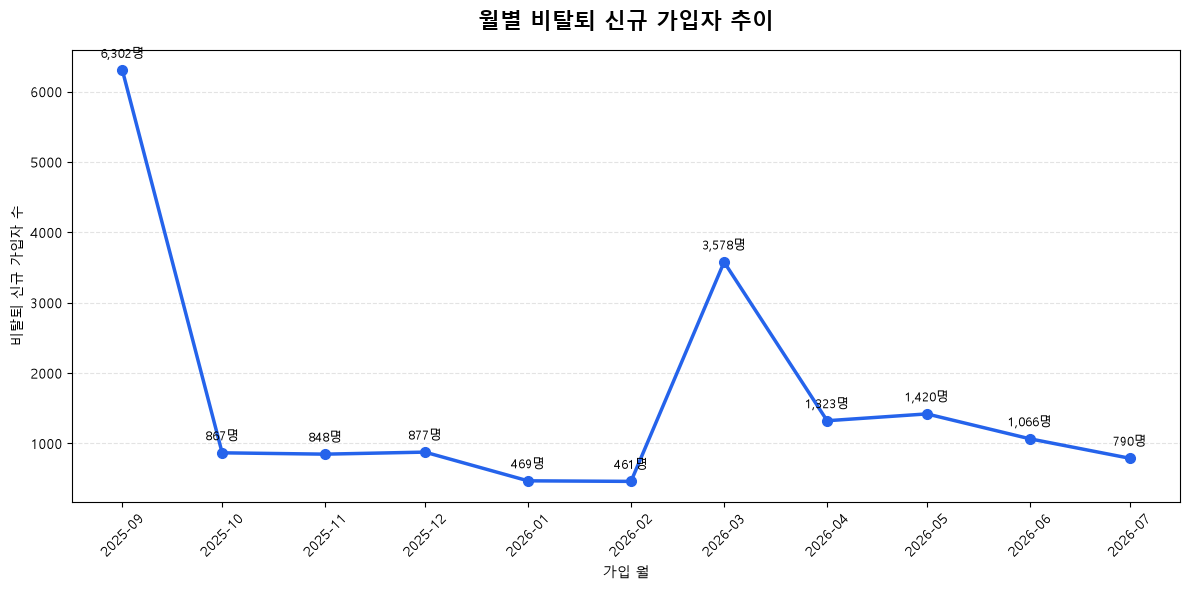

In [8]:
import platform
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

chart_df = df_monthly_non_withdrawn.copy()

chart_df["signup_month"] = pd.to_datetime(
    chart_df["signup_month"]
)

chart_df = chart_df.sort_values("signup_month")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    chart_df["signup_month"],
    chart_df["new_user_count"],
    color="#2563EB",
    marker="o",
    markersize=7,
    linewidth=2.5
)

# 월별 가입자 수 표시
for x, y in zip(
    chart_df["signup_month"],
    chart_df["new_user_count"]
):
    ax.annotate(
        f"{y:,}명",
        xy=(x, y),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

ax.set_title(
    "월별 비탈퇴 신규 가입자 추이",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("가입 월")
ax.set_ylabel("비탈퇴 신규 가입자 수")
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
grade_non_withdrawn_signup_sql = """
WITH acquisition_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id,
    u.class_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

grade_signup AS (
  SELECT
    s.school_type,
    gc.grade,
    COUNT(DISTINCT u.user_id) AS user_count

  FROM acquisition_users AS u

  JOIN `ping-v2-503916.raw.grade_class` AS gc
    ON gc._source = 'local'
   AND u.class_id = gc.id
   AND gc._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.school` AS s
    ON s._source = gc._source
   AND gc.school_id = s.id
   AND s._deleted_at IS NULL

  GROUP BY
    s.school_type,
    gc.grade
)

SELECT
  school_type,
  grade,
  user_count,

  -- 같은 학교 유형 안에서 해당 학년이 차지하는 비율
  ROUND(
    SAFE_DIVIDE(
      user_count,
      SUM(user_count) OVER (
        PARTITION BY school_type
      )
    ) * 100,
    2
  ) AS school_type_share_percent,

  -- 전체 18,001명 중 해당 학교 유형·학년의 비율
  ROUND(
    SAFE_DIVIDE(
      user_count,
      SUM(user_count) OVER ()
    ) * 100,
    2
  ) AS total_share_percent

FROM grade_signup
ORDER BY
  school_type,
  grade
"""

In [10]:
cost(grade_non_withdrawn_signup_sql)

예상 스캔량: 0.648 MiB
예상 스캔량: 0.000633 GiB
월 1 TiB 무료 용량의 약 0.00006183%


0.0006331680342555046

In [11]:
df_grade_non_withdrawn = bq.query(
    grade_non_withdrawn_signup_sql
).to_dataframe()

df_grade_non_withdrawn

,school_type,grade,user_count,school_type_share_percent,total_share_percent
0,HIGH,1,3463,33.44,19.24
1,HIGH,2,3477,33.57,19.32
2,HIGH,3,3416,32.99,18.98
3,MIDDLE,1,2536,33.17,14.09
4,MIDDLE,2,2548,33.33,14.15
5,MIDDLE,3,2561,33.50,14.23


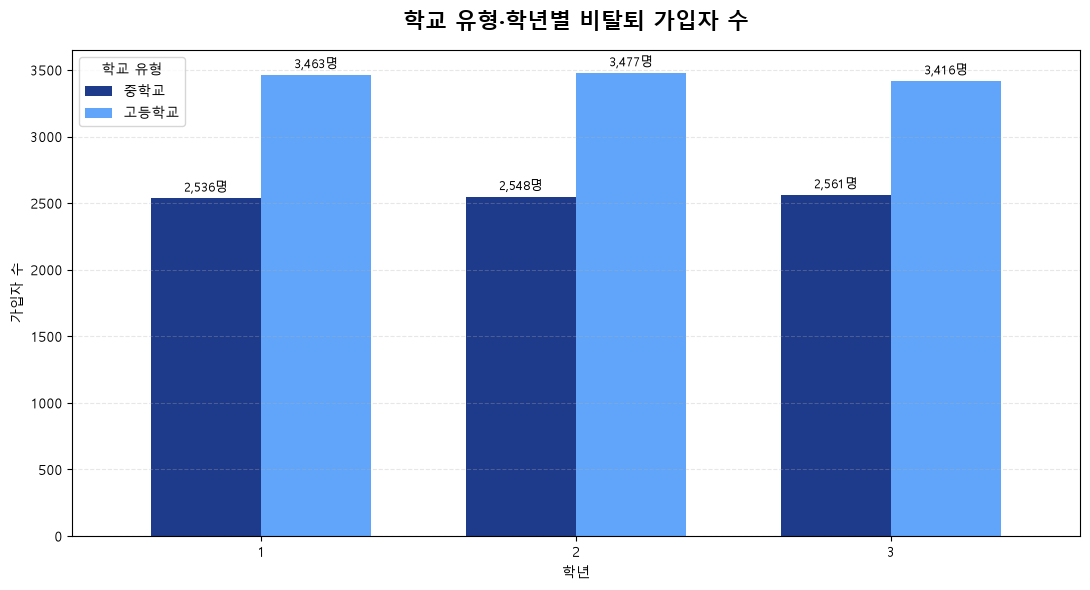

In [12]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

grade_chart = df_grade_non_withdrawn.copy()

# 학교 유형을 한글로 변경
grade_chart["school_type_label"] = (
    grade_chart["school_type"].replace({
        "MIDDLE": "중학교",
        "HIGH": "고등학교",
        "M": "중학교",
        "H": "고등학교"
    })
)

# 행은 학년, 열은 학교 유형
grade_pivot = grade_chart.pivot_table(
    index="grade",
    columns="school_type_label",
    values="user_count",
    aggfunc="sum",
    fill_value=0
)

# 중학교 → 고등학교 순서로 정렬
column_order = [
    column
    for column in ["중학교", "고등학교"]
    if column in grade_pivot.columns
]

grade_pivot = grade_pivot[column_order]

color_map = {
    "중학교": "#1E3A8A",
    "고등학교": "#60A5FA"
}

bar_colors = [
    color_map[column]
    for column in grade_pivot.columns
]

ax = grade_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    color=bar_colors,
    width=0.7
)

# 막대 위에 가입자 수 표시
for container in ax.containers:
    labels = [
        f"{bar.get_height():,.0f}명"
        if bar.get_height() > 0 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

ax.set_title(
    "학교 유형·학년별 비탈퇴 가입자 수",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("학년")
ax.set_ylabel("가입자 수")
ax.legend(title="학교 유형")
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
region_non_withdrawn_signup_sql = """
WITH acquisition_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id,
    u.class_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

region_user_count AS (
  -- 시도별 비탈퇴 가입자 수
  SELECT
    r.sido,
    COUNT(DISTINCT u.user_id) AS user_count

  FROM acquisition_users AS u

  JOIN `ping-v2-503916.raw.grade_class` AS gc
    ON gc._source = 'local'
   AND u.class_id = gc.id
   AND gc._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.school` AS s
    ON s._source = gc._source
   AND gc.school_id = s.id
   AND s._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.region` AS r
    ON r._source = s._source
   AND s.region_id = r.id
   AND r._deleted_at IS NULL

  GROUP BY r.sido
),

region_school_count AS (
  -- 시도별 전체 학교 수
  SELECT
    r.sido,
    COUNT(DISTINCT s.id) AS school_count

  FROM `ping-v2-503916.raw.school` AS s

  JOIN `ping-v2-503916.raw.region` AS r
    ON r._source = s._source
   AND s.region_id = r.id
   AND r._deleted_at IS NULL

  WHERE s._source = 'local'
    AND s._deleted_at IS NULL

  GROUP BY r.sido
)

SELECT
  u.sido,
  u.user_count,
  s.school_count,

  ROUND(
    SAFE_DIVIDE(
      u.user_count,
      s.school_count
    ),
    2
  ) AS users_per_school

FROM region_user_count AS u

JOIN region_school_count AS s
  ON u.sido = s.sido

ORDER BY u.user_count DESC
"""

In [17]:
cost(region_non_withdrawn_signup_sql)

예상 스캔량: 0.653 MiB
예상 스캔량: 0.000638 GiB
월 1 TiB 무료 용량의 약 0.00006229%


0.0006377995014190674

In [18]:
df_region_non_withdrawn = bq.query(
    region_non_withdrawn_signup_sql
).to_dataframe()

df_region_non_withdrawn

,sido,user_count,school_count,users_per_school
0,부산광역시,4432,11,402.91
1,경기도,3375,9,375.00
2,전라남도,2525,4,631.25
3,대구광역시,2248,6,374.67
4,강원특별자치도,2234,5,446.80
5,경상남도,1392,3,464.00
6,서울특별시,1056,7,150.86
7,충청남도,575,3,191.67
8,인천광역시,106,1,106.00
9,경상북도,58,1,58.00


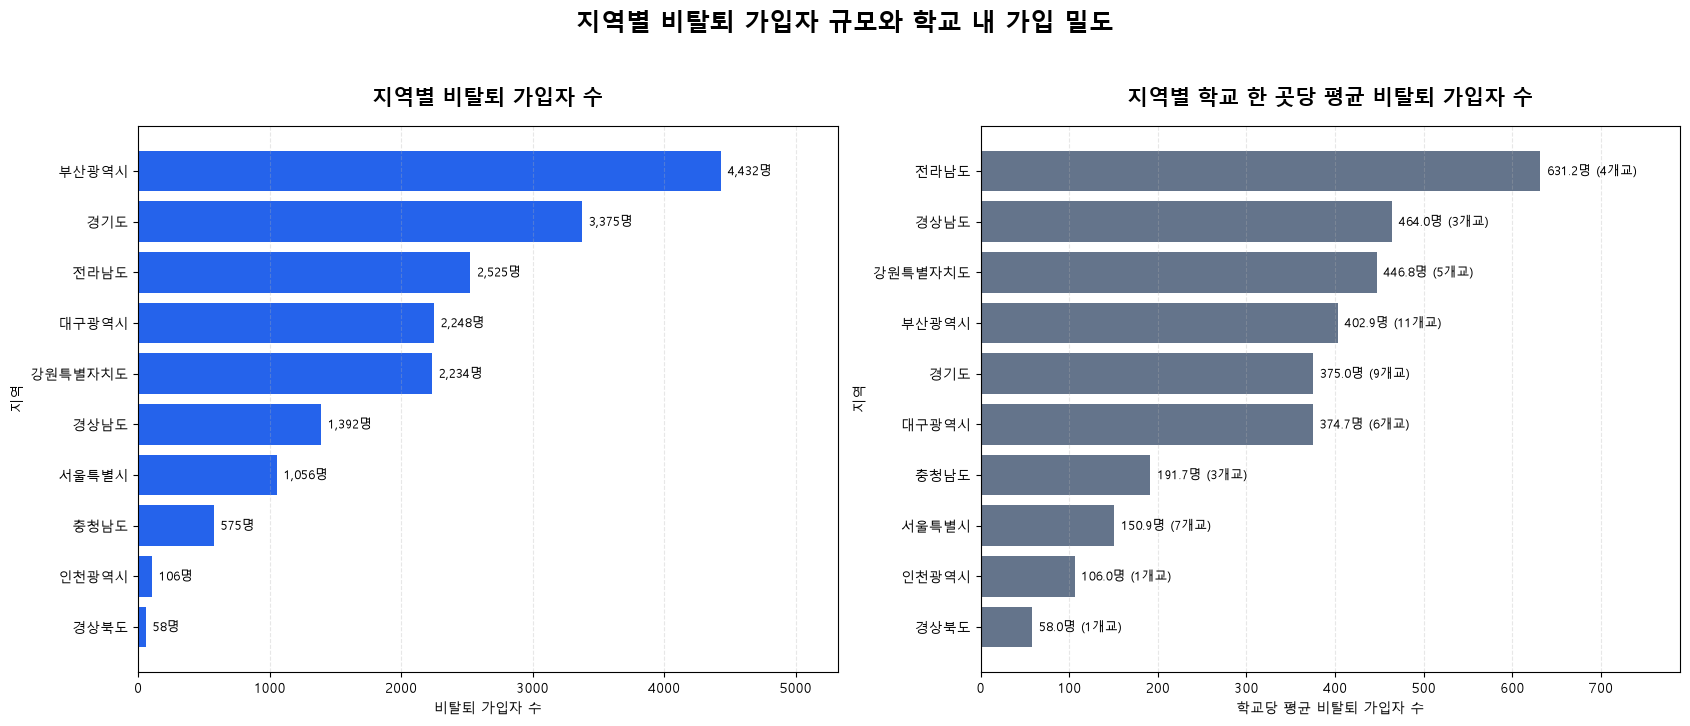

In [20]:
import platform
import matplotlib.pyplot as plt

# 운영체제별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

# 그래프별 정렬
count_chart = (
    df_region_non_withdrawn
    .sort_values("user_count", ascending=True)
    .copy()
)

average_chart = (
    df_region_non_withdrawn
    .sort_values("users_per_school", ascending=True)
    .copy()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 7)
)

# --------------------------------------------------
# 왼쪽: 지역별 비탈퇴 가입자 수
# --------------------------------------------------

bars1 = axes[0].barh(
    count_chart["sido"],
    count_chart["user_count"],
    color="#2563EB"
)

axes[0].bar_label(
    bars1,
    labels=[
        f"{value:,.0f}명"
        for value in count_chart["user_count"]
    ],
    padding=5,
    fontsize=9
)

axes[0].set_title(
    "지역별 비탈퇴 가입자 수",
    fontsize=15,
    fontweight="bold",
    pad=15
)
axes[0].set_xlabel("비탈퇴 가입자 수")
axes[0].set_ylabel("지역")
axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[0].set_xlim(
    0,
    count_chart["user_count"].max() * 1.2
)

# --------------------------------------------------
# 오른쪽: 지역별 학교 한 곳당 평균 가입자 수
# --------------------------------------------------

bars2 = axes[1].barh(
    average_chart["sido"],
    average_chart["users_per_school"],
    color="#64748B"
)

axes[1].bar_label(
    bars2,
    labels=[
        f"{average:,.1f}명 ({school_count:,.0f}개교)"
        for average, school_count in zip(
            average_chart["users_per_school"],
            average_chart["school_count"]
        )
    ],
    padding=5,
    fontsize=9
)

axes[1].set_title(
    "지역별 학교 한 곳당 평균 비탈퇴 가입자 수",
    fontsize=15,
    fontweight="bold",
    pad=15
)
axes[1].set_xlabel("학교당 평균 비탈퇴 가입자 수")
axes[1].set_ylabel("지역")
axes[1].grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

axes[1].set_xlim(
    0,
    average_chart["users_per_school"].max() * 1.25
)

fig.suptitle(
    "지역별 비탈퇴 가입자 규모와 학교 내 가입 밀도",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [21]:
gender_non_withdrawn_signup_sql = """
WITH acquisition_users AS (
  -- 합성 가입자 중 탈퇴 기록이 없는 사용자
  SELECT
    u.id AS user_id,
    COALESCE(
      CAST(u.gender AS STRING),
      'UNKNOWN'
    ) AS gender

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

gender_count AS (
  SELECT
    gender,
    COUNT(DISTINCT user_id) AS user_count
  FROM acquisition_users
  GROUP BY gender
)

SELECT
  gender,
  user_count,

  ROUND(
    SAFE_DIVIDE(
      user_count,
      SUM(user_count) OVER ()
    ) * 100,
    2
  ) AS user_share_percent

FROM gender_count
ORDER BY user_count DESC
"""

In [22]:
cost(gender_non_withdrawn_signup_sql)

예상 스캔량: 0.372 MiB
예상 스캔량: 0.000364 GiB
월 1 TiB 무료 용량의 약 0.00003551%


0.00036365166306495667

In [23]:
df_gender_non_withdrawn = bq.query(
    gender_non_withdrawn_signup_sql
).to_dataframe()

df_gender_non_withdrawn

,gender,user_count,user_share_percent
0,F,10628,59.04
1,M,7373,40.96


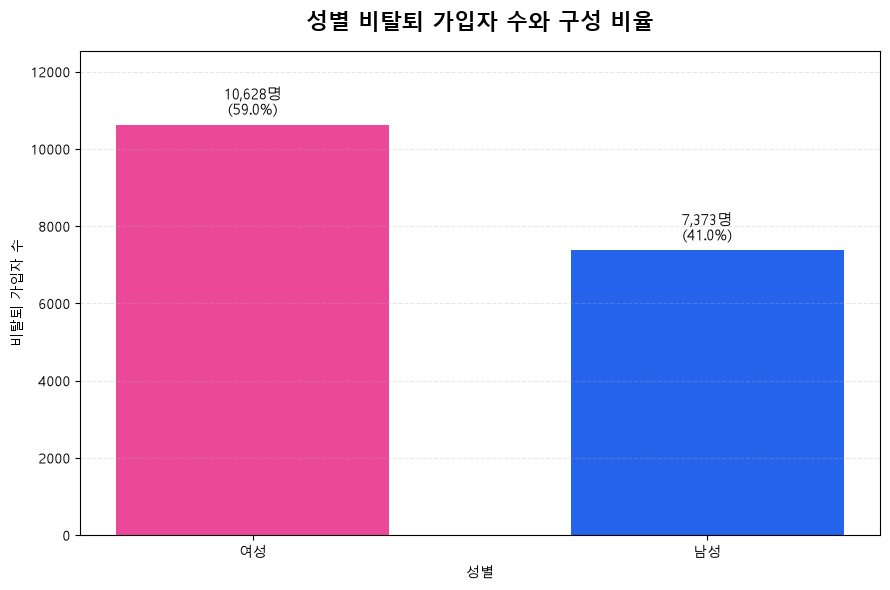

In [24]:
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

gender_chart = df_gender_non_withdrawn.copy()

gender_chart["gender_label"] = (
    gender_chart["gender"].replace({
        "F": "여성",
        "FEMALE": "여성",
        "M": "남성",
        "MALE": "남성",
        "UNKNOWN": "미입력"
    })
)

color_map = {
    "여성": "#EC4899",
    "남성": "#2563EB",
    "미입력": "#94A3B8"
}

bar_colors = [
    color_map.get(gender, "#64748B")
    for gender in gender_chart["gender_label"]
]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    gender_chart["gender_label"],
    gender_chart["user_count"],
    color=bar_colors,
    width=0.6
)

labels = [
    f"{count:,.0f}명\n({share:.1f}%)"
    for count, share in zip(
        gender_chart["user_count"],
        gender_chart["user_share_percent"]
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=5,
    fontsize=11
)

ax.set_title(
    "성별 비탈퇴 가입자 수와 구성 비율",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("성별")
ax.set_ylabel("비탈퇴 가입자 수")
ax.set_ylim(
    0,
    gender_chart["user_count"].max() * 1.18
)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()